In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# cols [list_size,threads,err,time,qsort_time]
data = open('out.txt','r')
D = []
for line in data:
    L = line.split(',')
    for i in range(len(L)):
        L[i] = float(L[i].split(' ')[-1])
    D.append(L)
labels = ['list_size','threads','err','time (s)', 'qsort_time (s)']
print(labels)
for i in D:
    print(i)
D = np.array(D)
print(D)

['list_size', 'threads', 'err', 'time (s)', 'qsort_time (s)']
[4096.0, 1.0, 0.0, 0.0005, 0.0003]
[4096.0, 2.0, 0.0, 0.0004, 0.0004]
[4096.0, 4.0, 0.0, 0.0004, 0.0004]
[4096.0, 16.0, 0.0, 0.0008, 0.0004]
[4096.0, 64.0, 0.0, 0.0028, 0.0004]
[4096.0, 256.0, 0.0, 0.0126, 0.0004]
[4096.0, 1024.0, 0.0, 0.0553, 0.0004]
[1048576.0, 1.0, 0.0, 0.1067, 0.1316]
[1048576.0, 2.0, 0.0, 0.0565, 0.132]
[1048576.0, 4.0, 0.0, 0.0343, 0.1309]
[1048576.0, 16.0, 0.0, 0.0181, 0.1317]
[1048576.0, 64.0, 0.0, 0.0173, 0.1328]
[1048576.0, 256.0, 0.0, 0.0251, 0.1322]
[1048576.0, 1024.0, 0.0, 0.0703, 0.133]
[268435456.0, 1.0, 0.0, 36.9733, 46.4623]
[268435456.0, 2.0, 0.0, 19.312, 46.3775]
[268435456.0, 4.0, 0.0, 10.2813, 46.4079]
[268435456.0, 16.0, 0.0, 4.053, 46.462]
[268435456.0, 64.0, 0.0, 3.0168, 46.6359]
[268435456.0, 256.0, 0.0, 2.7934, 46.4531]
[268435456.0, 1024.0, 0.0, 2.8922, 46.364]
[[4.09600000e+03 1.00000000e+00 0.00000000e+00 5.00000000e-04
  3.00000000e-04]
 [4.09600000e+03 2.00000000e+00 0.00000000

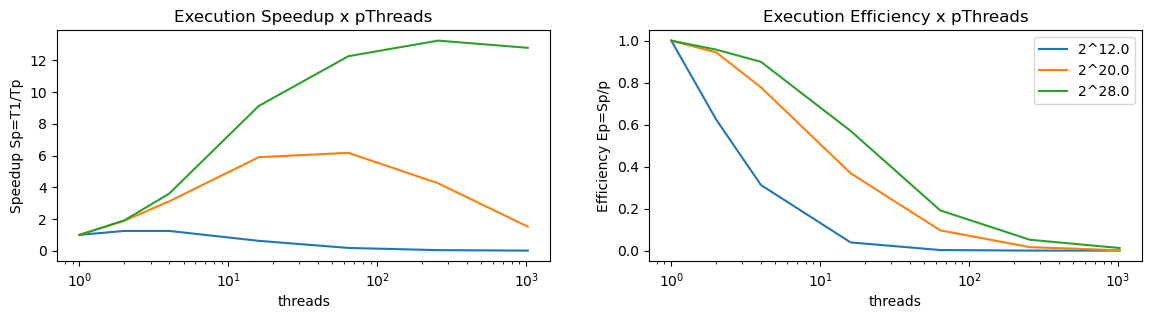

In [7]:
x,y1,y2 = [],[],[]
T1 = D[0][3]
for row in D[:7]:
    x.append(row[1])
    S = T1/row[3]
    y1.append(S)
    y2.append(S/row[1])
T1 = D[7][3]
for row in D[7:14]:
    x.append(row[1])
    S = T1/row[3]
    y1.append(S)
    y2.append(S/row[1])
T1 = D[14][3]
for row in D[14:]:
    x.append(row[1])
    S = T1/row[3]
    y1.append(S)
    y2.append(S/row[1])

fig, ax = plt.subplots(1,2, figsize=(14, 3))
ax[0].plot(x[:7], y1[:7], label=f'2^{np.log2(D[0][0])}')
ax[0].plot(x[7:14], y1[7:14], label=f'2^{np.log2(D[7][0])}')
ax[0].plot(x[14:], y1[14:], label=f'2^{np.log2(D[14][0])}')
ax[0].set_xscale('log')
ax[0].set_xlabel(labels[1])
ax[0].set_ylabel('Speedup Sp=T1/Tp')
ax[0].set_title('Execution Speedup x pThreads')

ax[1].plot(x[:7], y2[:7], label=f'2^{np.log2(D[0][0])}')
ax[1].plot(x[7:14], y2[7:14], label=f'2^{np.log2(D[7][0])}')
ax[1].plot(x[14:], y2[14:], label=f'2^{np.log2(D[14][0])}')
ax[1].set_xscale('log')
ax[1].set_xlabel(labels[1])
ax[1].set_ylabel('Efficiency Ep=Sp/p')
ax[1].set_title('Execution Efficiency x pThreads')

handles, labels_leg = ax[0].get_legend_handles_labels()
ax[1].legend(handles, labels_leg, loc='upper right')

plt.show()